In [2]:
import pandas as pd
import urllib.request
import os

data_dir = '../data'
file_path = os.path.join(data_dir, 'student-mat.csv')
url = "https://raw.githubusercontent.com/sarthak-srivastava/Student-Performance-Dataset/master/student-mat.csv"

print("Downloading dataset directly into your /data folder...")
urllib.request.urlretrieve(url, file_path)
print("Download complete! File saved safely.")

df = pd.read_csv(file_path, sep=';')
print(f"\nDataset loaded successfully! Shape of data: {df.shape}")
df.head()

Download complete! File saved safely.

Dataset loaded successfully! Shape of data: (395, 1)


,"school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3"
0,"GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mot..."
1,"GP,F,17,U,GT3,T,1,1,at_home,other,course,fathe..."
2,"GP,F,15,U,LE3,T,1,1,at_home,other,other,mother..."
3,"GP,F,15,U,GT3,T,4,2,health,services,home,mothe..."
4,"GP,F,16,U,GT3,T,3,3,other,other,home,father,1,..."


In [3]:
# Fix the separator by changing it to a comma
df = pd.read_csv('../data/student-mat.csv', sep=',')

# Let's verify the new shape and look at the clean grid
print(f"Fixed Shape of data: {df.shape}")
df.head()


Fixed Shape of data: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
# 1. Create a binary column: 1 if final grade G3 is less than 10, otherwise 0
df['at_risk'] = (df['G3'] < 10).astype(int)

# 2. Print out the exact counts of students
print("Number of students in each category:")
print(df['at_risk'].value_counts())

Number of students in each category:
at_risk
0    265
1    130
Name: count, dtype: int64


Matplotlib is building the font cache; this may take a moment.
C:\Users\thete\AppData\Local\Temp\ipykernel_32008\966827460.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='at_risk', y='absences', data=df, palette='Set2')


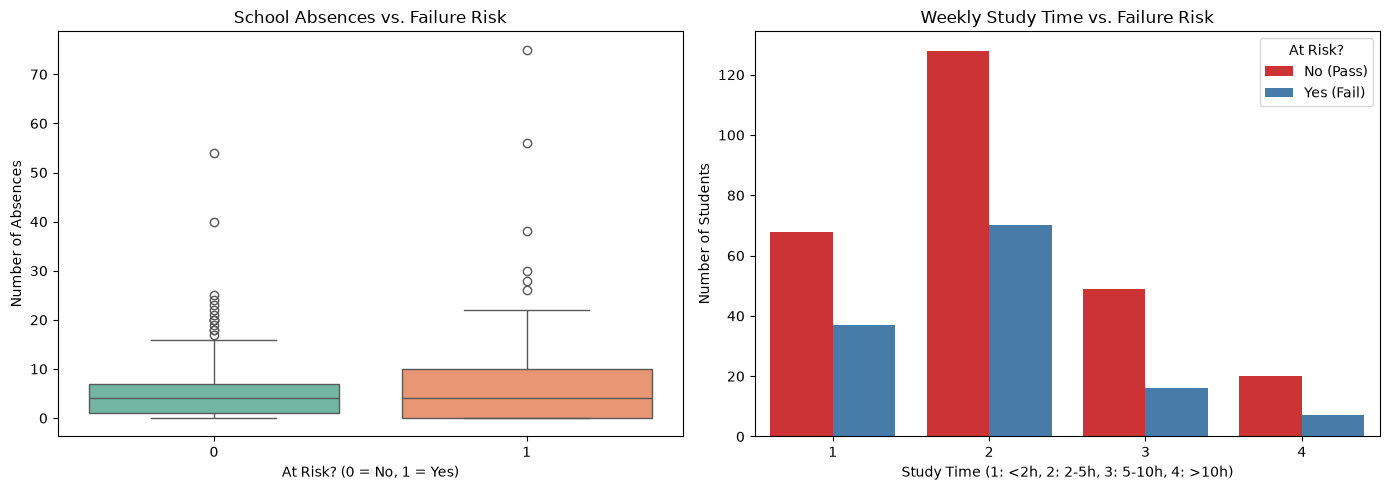

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Set up the plotting area
plt.figure(figsize=(14, 5))

# Graph 1: Absences vs Risk
plt.subplot(1, 2, 1)
sns.boxplot(x='at_risk', y='absences', data=df, palette='Set2')
plt.title('School Absences vs. Failure Risk')
plt.xlabel('At Risk? (0 = No, 1 = Yes)')
plt.ylabel('Number of Absences')

# Graph 2: Study Time vs Risk
plt.subplot(1, 2, 2)
sns.countplot(x='studytime', hue='at_risk', data=df, palette='Set1')
plt.title('Weekly Study Time vs. Failure Risk')
plt.xlabel('Study Time (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h)')
plt.ylabel('Number of Students')
plt.legend(title='At Risk?', labels=['No (Pass)', 'Yes (Fail)'])

plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

# 1. Separate features (X) from the target answer (y)
# We drop 'G3' because 'at_risk' was made from it. Keeping it would be cheating!
X = df.drop(columns=['G3', 'at_risk'])
y = df['at_risk']

# 2. One-Hot Encode all categorical text columns automatically
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Split data: 80% for training the AI, 20% held back to test it
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Data successfully prepared!")
print(f"Training features size: {X_train.shape}")
print(f"Testing features size: {X_test.shape}")

Data successfully prepared!
Training features size: (316, 41)
Testing features size: (79, 41)


In [7]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.6/101.7 MB 11.6 MB/s eta 0:00:09
   - -------------------------------------- 4.7/101.7 MB 13.6 MB/s eta 0:00:08
   --- ------------------------------------ 8.1/101.7 MB 14.3 MB/s eta 0:00:07
   ---- ----------------------------------- 12.1/101.7 MB 15.8 MB/s eta 0:00:06
   ------ --------------------------------- 16.3/101.7 MB 16.5 MB/s eta 0:00:06
   -------- ------------------------------- 21.2/101.7 MB 17.9 MB/s eta 0:00:05
   ---------- ----------------------------- 27.5/101.7 MB 19.7 MB/s eta 0:00:04
   ------------- -------------------------- 34.6/101.7 MB 21.7 MB/s eta 0:00:04
   ---------------- ----------------------- 42.5/101.7 MB 23.2 MB/s eta 0:00:03
   ------------------- -------------------- 49.5/101.7 MB 24.4 MB/s eta 0:00:03
   ---------------------- ----------------- 57.9/101.7 MB 25.7 MB/s eta 0:00:02
   ------------------------- -------------- 64.7/101


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the XGBoost Model
model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_seed=42)

# 2. Train the model using our training data
model.fit(X_train, y_train)

# 3. Make predictions on the hidden test data
y_pred = model.predict(X_test)

# 4. Check how well it did
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))

D:\Projects\failsafe\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:55:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "random_seed" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model Accuracy: 92.41%

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        53
           1       0.88      0.88      0.88        26

    accuracy                           0.92        79
   macro avg       0.91      0.91      0.91        79
weighted avg       0.92      0.92      0.92        79



In [9]:
!pip install shap

   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ------ --------------------------------- 5.8/38.1 MB 24.1 MB/s eta 0:00:02
   -------------- ------------------------- 13.6/38.1 MB 29.1 MB/s eta 0:00:01
   ---------------------- ----------------- 21.5/38.1 MB 30.2 MB/s eta 0:00:01
   ------------------------------- -------- 29.6/38.1 MB 30.8 MB/s eta 0:00:01
   ---------------------------------------  37.2/38.1 MB 30.8 MB/s eta 0:00:01
   ---------------------------------------  38.0/38.1 MB 30.7 MB/s eta 0:00:01
   ---------------------------------------  38.0/38.1 MB 30.7 MB/s eta 0:00:01
   ---------------------------------------- 38.1/38.1 MB 21.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   -------------------------------------- - 2.6/2.8 MB 124.1 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 9.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


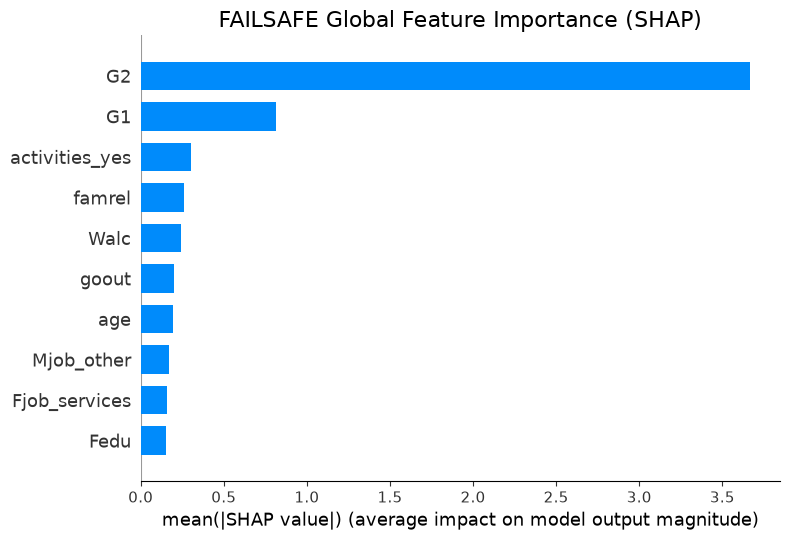

In [10]:
import shap

# 1. Initialize the SHAP explainer with our trained model
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)

# 2. Plot the summary chart (Feature Importance)
plt.title("FAILSAFE Global Feature Importance (SHAP)", fontsize=16)
shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=10)

In [11]:
import joblib

# Save the trained model file into our /models folder
joblib.dump(model, '../models/failsafe_xgb_model.pkl')

# Save our column names so the backend knows the exact order of features
joblib.dump(X_train.columns.tolist(), '../models/model_features.pkl')

print("Success! Model engine and feature schema saved permanently to the /models folder.")

Success! Model engine and feature schema saved permanently to the /models folder.
